Some simple statistics

In [1]:
import os
import glob
import numpy as np # for arrays
import pandas as pd # for importing csv files
from pathlib import Path
import matplotlib.pyplot as plt

Read file extensions and plot them. I expect m4a, mp3, wav and opus

In [4]:
# folder that contains two subfolders "germany" and "usa"
measCsv=r'C:\Users\t_ziemer\Desktop\techno-mfccbpm'
folds=glob.glob(str(measCsv+'\\*'))
# dictionary of all features:
features = {1: 'MFCC1',
            2: 'MFCC2',
            3: 'MFCC3',
            4: 'MFCC4',
            5: 'MFCC5',
            6: 'MFCC6',
            7: 'MFCC7',
            8: 'MFCC8',
            9: 'MFCC9',
            10: 'MFCC10',
            11: 'MFCC11',
            12: 'MFCC12',
            13: 'MFCC13',
            14: 'SpectralCentroid',
            15: 'SpectralRolloff',
            16: 'SpectralFlatness',
            17: 'SpectralBandwidth',
            18: 'ZeroCrossingRate',
           19: 'bpm'}

# selection of preferred features
nfeatures = {0: 1,
             1: 2,
             2: 3,
             3: 4,
             4:5, 5:6, 6:7, 7:8, 8:9, 9:10, 10:11, 11:12, 12:13, 13:14, 14:15, 15:16, 16:17, 17:18, 18:19
            }
numfeatures = len(nfeatures)

In [5]:
# median: takes forever, only works when ALL filenames are correct

train_X = []
target = []
phase_space = []
phase_space_low = []
phase_space_mid = []
phase_space_high = []

channel_corr = []
channel_corr_low = []
channel_corr_mid = []
channel_corr_high = []

peak_meter = []
peak_meter_low = []
peak_meter_mid = []
peak_meter_high = []

rms_meter = []
rms_meter_low = []
rms_meter_mid = []
rms_meter_high = []

crest_factor = []
crest_factor_low = []
crest_factor_mid = []
crest_factor_high = []

color_map = {}
nation = []
year = []
filename = []

# give the classes their names
labels=['Germany','USA']

for cl, fold in enumerate(folds):
    files = glob.glob(str(fold+'\*.csv'))
    numfiles = len(fold)
    lal1 = np.empty((numfiles, numfeatures))
    #print(lal1)
    for j, f in enumerate(files):
        la = pd.read_csv(f, index_col=0)
        phase_space.append(la[features[nfeatures[0]]].median())
        channel_corr.append(la[features[nfeatures[1]]].median())
        peak_meter.append(la[features[nfeatures[2]]].median())
        rms_meter.append(la[features[nfeatures[3]]].median())
        crest_factor.append(la[features[nfeatures[4]]].median())
        
        phase_space_low.append(la[features[nfeatures[5]]].median())
        channel_corr_low.append(la[features[nfeatures[6]]].median())
        peak_meter_low.append(la[features[nfeatures[7]]].median())
        rms_meter_low.append(la[features[nfeatures[8]]].median())
        crest_factor_low.append(la[features[nfeatures[9]]].median())
        
        phase_space_mid.append(la[features[nfeatures[10]]].median())
        channel_corr_mid.append(la[features[nfeatures[11]]].median())
        peak_meter_mid.append(la[features[nfeatures[12]]].median())
        rms_meter_mid.append(la[features[nfeatures[13]]].median())
        crest_factor_mid.append(la[features[nfeatures[14]]].median())
        
        phase_space_high.append(la[features[nfeatures[15]]].median())
        channel_corr_high.append(la[features[nfeatures[16]]].median())
        peak_meter_high.append(la[features[nfeatures[17]]].median())
        rms_meter_high.append(la[features[nfeatures[18]]].median())
     
        
        #reads the year from the filename:
        if f[-5]=='s':# opus files
            year.append(int(f[-14:-10]))
            opus = -16
        else:# for mp4/m4a/wav files
            year.append(int(f[-13:-9]))
            opus = -15
        if fold[-1]=='y':# for the "germany" folder
            filename.append(f[49:opus])# this number depends on absolute file path
        else:
            filename.append(f[45:opus])# this number depends on absolute file path
            #print(f[45:-16])
        nation.append(labels[cl])

In [6]:
# ensures that every song has a valid year
nan_indices = [index for index, value in enumerate(train_X) if np.isnan(value)]
print(nan_indices)

[]


In [16]:
filename = [f[4:] for f in filename]

In [18]:
# produces a massive csv file that contains all releven info
matrix = np.array([filename,nation,year,phase_space,channel_corr,peak_meter,rms_meter,crest_factor,phase_space_low,channel_corr_low,peak_meter_low,rms_meter_low,crest_factor_low,phase_space_mid,channel_corr_mid,peak_meter_mid,rms_meter_mid,crest_factor_mid,phase_space_high,channel_corr_high,peak_meter_high,rms_meter_high])
matrix = matrix.transpose()
df = pd.DataFrame(matrix, columns=['Song','Nation', 'Year','MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6','MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12','MFCC13','SpectralCentroid','SpectralRolloff','SpectralFlatness','SpectralBandwidth','ZeroCrossingRate','bpm'])
csvfilename = r'C:\python\gits\icmc\matrix25-12-25-allTimbremedian.csv'

# Save the array to a CSV file
df.to_csv(csvfilename, index=False, header=True)

In [27]:
import numpy as np # for arrays
import pandas as pd # for importing csv files
from pathlib import Path
#csvfilename = r'C:\python\gits\early-techno\matrix25-02-22-all21median.csv'
#csvfilename = r'C:\python\gits\early-techno\matrix25-02-22-all21sd.csv'
#csvfilename = r'C:\python\gits\early-techno\matrix25-02-22-all21mean.csv'
csvfilename = r'C:\python\gits\early-techno\matrix25-02-24-all21skew.csv'
df = pd.read_csv(csvfilename, index_col=False)

Check for Multicollinearity:

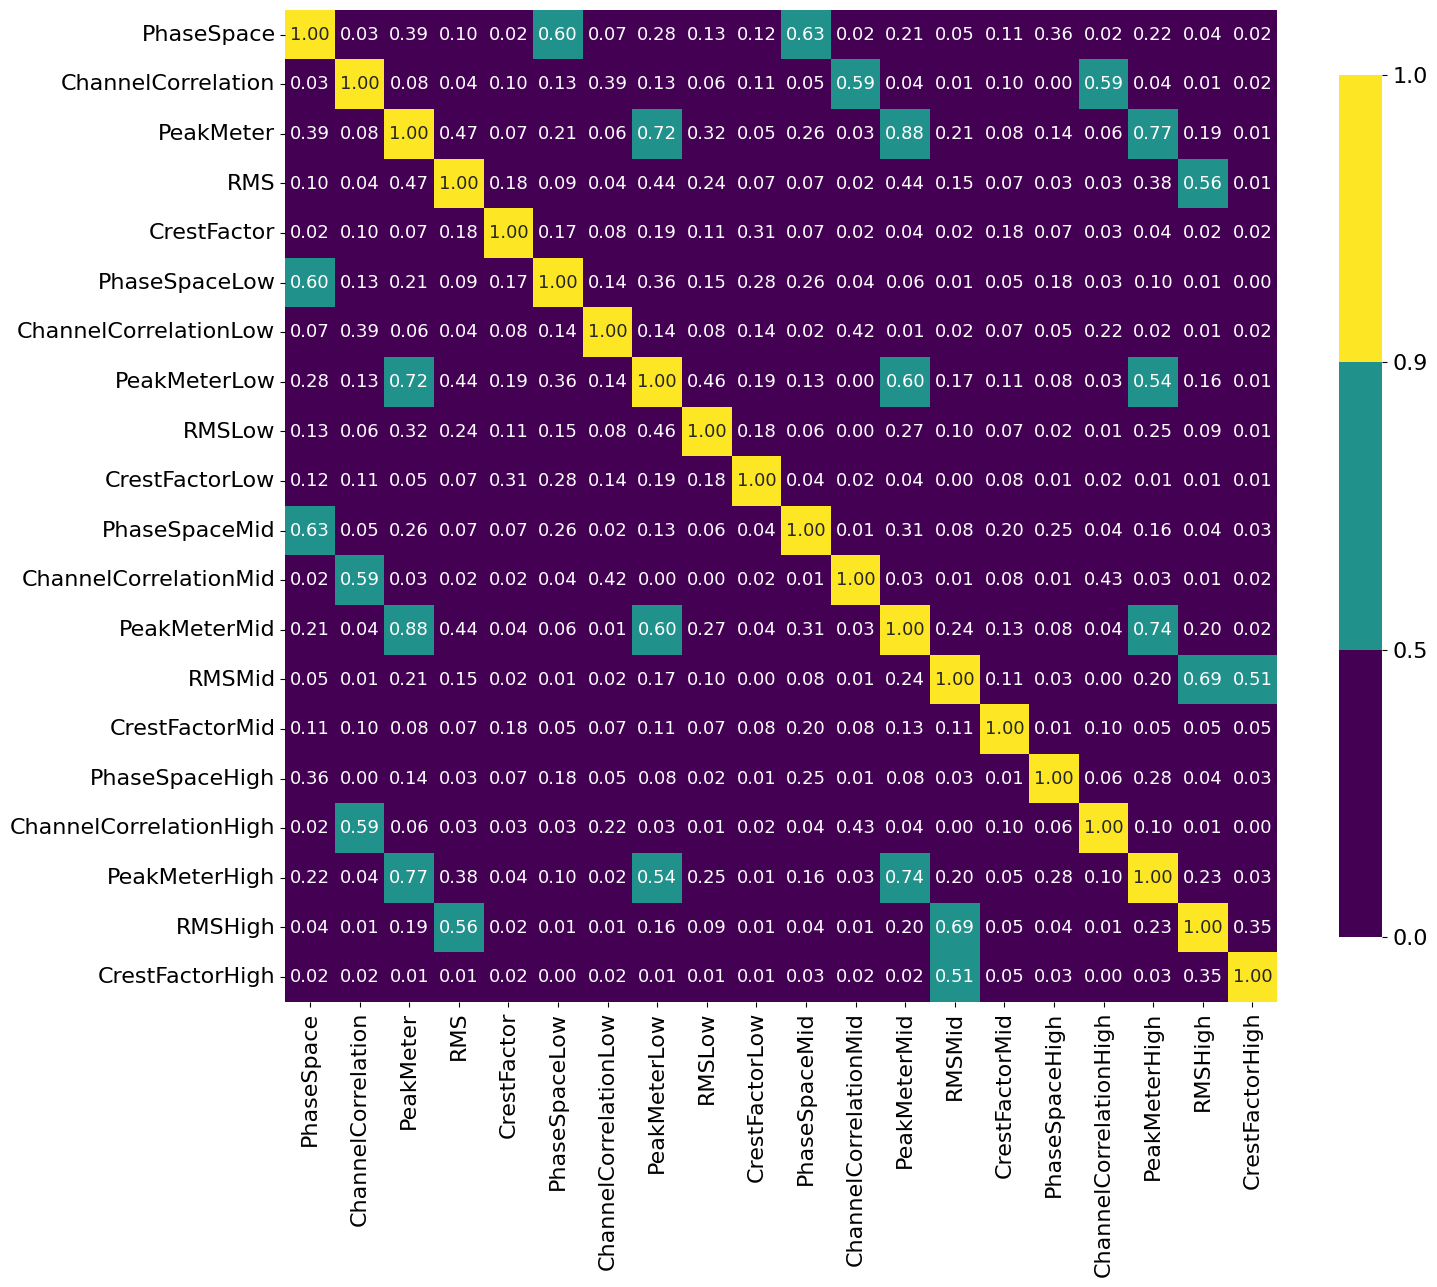

In [28]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import get_cmap
import seaborn as sns

df_selected = df.iloc[:, 3:]
correlation_matrix = df_selected.corr()

# Take the absolute value
abs_correlation_matrix = correlation_matrix.abs()

# Set up the matplotlib figure
plt.figure(figsize=(16, 14))

# Get viridis color map and sample specific colors for the defined ranges
viridis_cmap = get_cmap('viridis')
colors = [viridis_cmap(viridis_cmap.N // 4 * 0),   # Blue (lower range)
          viridis_cmap(viridis_cmap.N // 4 * 2),   # Green (middle range)
          viridis_cmap(viridis_cmap.N - 1)]         # Yellow (upper range)

# Create custom colormap and normalization
cmap = ListedColormap(colors)
boundaries = [0, 0.5, 0.9, 1]  # Define the boundaries for the color categories
norm = BoundaryNorm(boundaries, ncolors=len(colors), clip=False)

# Draw the heatmap
ax=sns.heatmap(abs_correlation_matrix, 
            annot=True,         # Annotate with the correlation values
            fmt=".2f",         # Format to two decimal places
            cmap=cmap,         # Use the custom colormap
            norm=norm,         # Use the custom normalization
            square=True,       # Make cells square
            annot_kws={"size": 13},  # Increase annotation size
            cbar_kws={"shrink": .8})  # Color bar size

cbar = ax.collections[0].colorbar  # Get the colorbar
cbar.ax.tick_params(labelsize=16) 
# Title and labels
ax.tick_params(axis='both', labelsize=16)  # Change tick label size
#plt.title('Discretized Absolute Spearman Correlation Matrix using Viridis')
plt.savefig('correlation_matrix_skewnew.pdf', format='pdf',bbox_inches='tight')
plt.show()

Two-way MANOVA

In [ ]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('PhaseSpace + ChannelCorrelation + PeakMeter + RMS + CrestFactor + PhaseSpaceLow + ChannelCorrelationLow + PeakMeterLow + RMSLow + CrestFactorLow + PhaseSpaceMid + ChannelCorrelationMid + PeakMeterMid + RMSMid + CrestFactorMid + PhaseSpaceHigh + ChannelCorrelationHigh + PeakMeterHigh + RMSHigh + CrestFactorHigh + bpm ~ Nation * Year', data=df)
# Print the results
print(manova.mv_test())

Correlation of tracks and record labels

In [ ]:
from scipy import stats

gertr=np.array([5,6,18,55,126,195,430,839,1191,1799])
gerla=np.array([2,4,7,9,17,24,41,58,69,81])
gerye=np.array([1985,1986,1987,1988,1989,1990,1991,1992,1993,1994])
ustr=np.array([12,29,96,187,302,301,450,557,903,701,825])
usla=np.array([7,11,16,24,25,39,47,61,68,70,57])
usye=np.array([1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994])
pearson_corr, pearson_p_value = stats.pearsonr(gertr, gerla)
pearson_corr2, pearson_p_value2 = stats.pearsonr(ustr, usla)
print(f'ger: {pearson_corr}, p-value: {pearson_p_value}')
print(f'us: {pearson_corr2}, p-value: {pearson_p_value2}')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a bar plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first dataset (gertr)
bars1 = ax1.bar(np.arange(len(gertr)), gertr, color='dodgerblue', alpha=0.5, label='Tracks')
ax1.set_xlabel('Year',fontsize=20)
ax1.set_ylabel('Tracks', color='dodgerblue',fontsize=20)
ax1.tick_params(axis='y', labelcolor='dodgerblue',labelsize=16)

# Setting the custom x-ticks and labels
ax1.set_xticks(np.arange(len(gerye)))  # Set x-ticks to match the number of years
ax1.set_xticklabels(gerye, fontsize=16)  # Set custom tick labels

# Create a second y-axis for the second dataset (gerla)
ax2 = ax1.twinx()
bars2 = ax2.bar(np.arange(len(gerla)), gerla, color='blue', alpha=0.5, label='Labels', width=0.4)
ax2.set_ylabel('Labels', color='blue',fontsize=20)
ax2.tick_params(axis='y', labelcolor='blue',labelsize=12)

# Adding legends
fig.legend(loc='upper right', bbox_to_anchor=(0.3, 0.85), bbox_transform=ax1.transAxes,fontsize=20)

# Title and grid
#plt.title('Bar Diagram of Gertr and Gerla')
ax1.grid(True)

plt.savefig('tracks-labels-over-year-ger.pdf', bbox_inches='tight')

# Show the plot
plt.show()

In [ ]:
# Create a bar plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first dataset (gertr)
bars1 = ax1.bar(np.arange(len(ustr)), ustr, color='lightcoral', alpha=0.5, label='Tracks')
ax1.set_xlabel('Year',fontsize=20)
ax1.set_ylabel('Tracks', color='lightcoral',fontsize=20)
ax1.tick_params(axis='y', labelcolor='lightcoral',labelsize=16)

# Setting the custom x-ticks and labels
ax1.set_xticks(np.arange(len(usye)))  # Set x-ticks to match the number of years
ax1.set_xticklabels(usye, fontsize=16)  # Set custom tick labels

# Create a second y-axis for the second dataset (gerla)
ax2 = ax1.twinx()
bars2 = ax2.bar(np.arange(len(usla)), usla, color='red', alpha=0.5, label='Labels', width=0.4)
ax2.set_ylabel('Labels', color='red',fontsize=20)
ax2.tick_params(axis='y', labelcolor='red',labelsize=12)

# Adding legends
fig.legend(loc='upper right', bbox_to_anchor=(0.3, 0.85), bbox_transform=ax1.transAxes,fontsize=20)

# Title and grid
#plt.title('Bar Diagram of Gertr and Gerla')
ax1.grid(True)

plt.savefig('tracks-labels-over-year-usa.pdf', bbox_inches='tight')

# Show the plot
plt.show()